# ## 1. Ordering Patterns

**Business question:** When do customers usually place their orders?

This analysis examines the number of orders by day and hour.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

dim_user = pd.read_csv("../Dataset/dim_user_features.csv")
dim_product = pd.read_csv("../Dataset/dim_product.csv")
dim_order_slot = pd.read_csv("../Dataset/dim_order_slot.csv")
fact_order = pd.read_csv("../Dataset/fact_order.csv")

print("dim_user:", dim_user.shape)
print("dim_product:", dim_product.shape)
print("dim_order_slot:", dim_order_slot.shape)
print("fact_order:", fact_order.shape)

dim_user: (206209, 9)
dim_product: (49688, 6)
dim_order_slot: (168, 4)
fact_order: (3421083, 9)


### 1. Join order and time information

In [5]:
orders_with_time = fact_order.merge(
    dim_order_slot,
    on="slot_key",
    how="left"
)

print("Shape:", orders_with_time.shape)

orders_with_time[
    ["order_id", "order_dow", "order_hour_of_day", "day_part"]
].head()

Shape: (3421083, 12)


,order_id,order_dow,order_hour_of_day,day_part
0,2539329,2,8,Morning
1,2398795,3,7,Morning
2,473747,3,12,Afternoon
3,2254736,4,7,Morning
4,431534,4,15,Afternoon


#### 2. Orders by day

In [6]:
orders_by_day = (
    orders_with_time
    .groupby("order_dow")
    .size()
    .reset_index(name="order_count")
)

display(orders_by_day)

,order_dow,order_count
0,0,600905
1,1,587478
2,2,467260
3,3,436972
4,4,426339
5,5,453368
6,6,448761


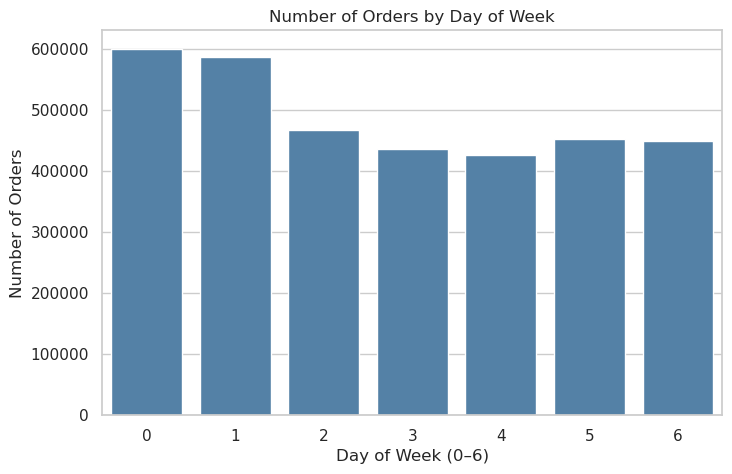

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=orders_by_day,
    x="order_dow",
    y="order_count",
    color="steelblue"
)

plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week (0–6)")
plt.ylabel("Number of Orders")
plt.ticklabel_format(style="plain", axis="y")
plt.show()

#### 3: Orders by hour

In [15]:
orders_by_hour = (
    orders_with_time
    .groupby("order_hour_of_day")
    .size()
    .reset_index(name="order_count")
)

display(orders_by_hour)

,order_hour_of_day,order_count
0,0,22758
1,1,12398
2,2,7539
3,3,5474
4,4,5527
5,5,9569
6,6,30529
7,7,91868
8,8,178201
9,9,257812


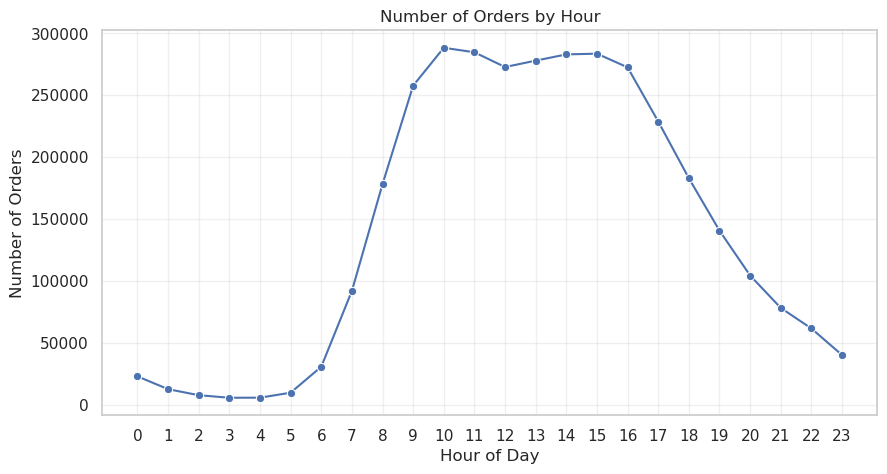

In [16]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=orders_by_hour,
    x="order_hour_of_day",
    y="order_count",
    marker="o"
)

plt.title("Number of Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(24))
plt.ticklabel_format(style="plain", axis="y")
plt.grid(alpha=0.3)
plt.show()

#### 4: Day-and-hour heatmap

In [17]:
day_hour_table = orders_with_time.pivot_table(
    index="order_dow",
    columns="order_hour_of_day",
    values="order_id",
    aggfunc="count",
    fill_value=0
)

display(day_hour_table)

order_hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
order_dow,,,,,,,,,,,,,,,,,,,,,
0,3936,2398,1409,963,813,1168,3329,12410,28108,40798,...,54552,53954,49463,39753,29572,22654,18277,14423,11246,6887
1,3674,1830,1105,748,809,1607,5370,16571,34116,51908,...,46764,46403,44761,36792,28977,22145,16281,11943,8992,5620
2,3059,1572,943,719,744,1399,4758,13245,24635,36314,...,37173,37469,37541,32151,26470,20084,15039,10653,8146,5358
3,2952,1495,953,654,719,1355,4562,12396,22553,32312,...,34773,35990,35273,30368,25001,19249,13795,10278,8242,5181
4,2642,1512,899,686,730,1330,4401,12493,21814,31409,...,33625,34222,34093,29378,24425,19350,14186,10796,8812,5645
5,3189,1672,1016,841,910,1574,4866,13434,24015,34232,...,37407,37508,35860,29955,24310,18741,13322,9515,7498,5265
6,3306,1919,1214,863,802,1136,3243,11319,22960,30839,...,38748,38093,35562,30398,24157,18346,13392,10501,8532,6087


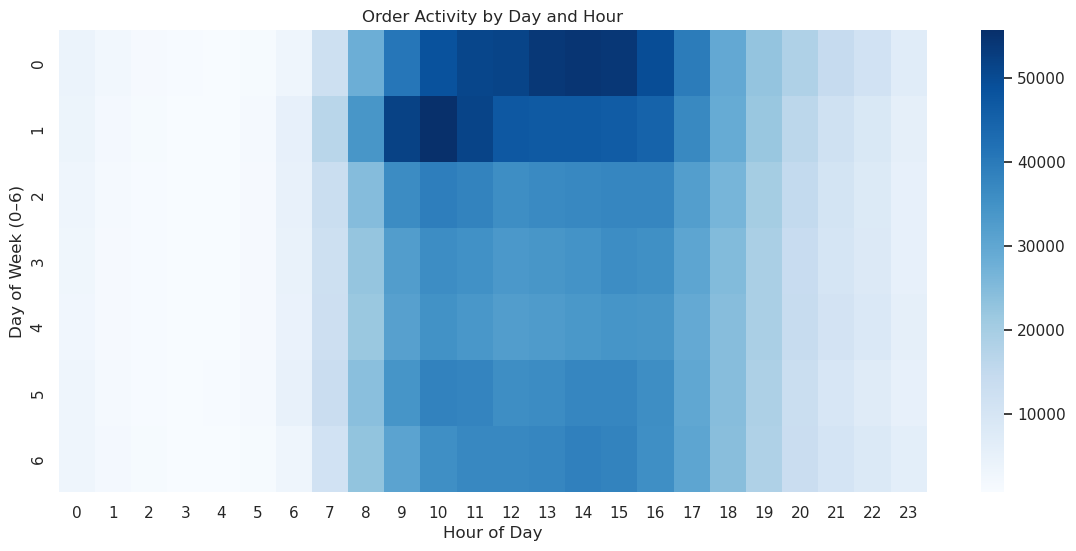

In [13]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    day_hour_table,
    cmap="Blues"
)

plt.title("Order Activity by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0–6)")
plt.show()

#### 5: Identify the peak periods

In [18]:
peak_day = orders_by_day.loc[
    orders_by_day["order_count"].idxmax()
]

peak_hour = orders_by_hour.loc[
    orders_by_hour["order_count"].idxmax()
]

print(
    f"Highest-order day: Day {int(peak_day['order_dow'])} "
    f"with {int(peak_day['order_count']):,} orders"
)

print(
    f"Highest-order hour: {int(peak_hour['order_hour_of_day'])}:00 "
    f"with {int(peak_hour['order_count']):,} orders"
)

Highest-order day: Day 0 with 600,905 orders
Highest-order hour: 10:00 with 288,418 orders


# EDA 2: Basket-size behaviour


## 2. Basket-Size Behaviour

**Business question:** How many products do customers usually purchase in one order?

Only orders with a known basket size are included. Test orders contain
meaningful missing basket-size values because their product details are unavailable.

#### 1. Prepare basket-size data

In [19]:
basket_data = fact_order["basket_size"].dropna()

print("Orders analysed:", f"{len(basket_data):,}")
print("Average basket size:", round(basket_data.mean(), 2))
print("Median basket size:", round(basket_data.median(), 2))
print("Minimum basket size:", int(basket_data.min()))
print("Maximum basket size:", int(basket_data.max()))

Orders analysed: 3,346,083
Average basket size: 10.11
Median basket size: 8.0
Minimum basket size: 1
Maximum basket size: 145


#### 2: Display summary statistics

In [20]:
basket_data.describe()

count    3.346083e+06
mean     1.010707e+01
std      7.542326e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: basket_size, dtype: float64

#### 3: Draw the distribution

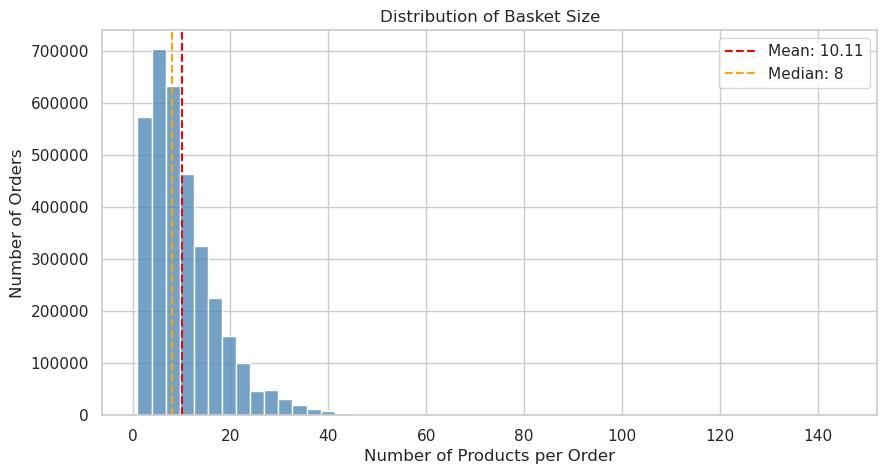

In [21]:
average_basket = basket_data.mean()
median_basket = basket_data.median()

plt.figure(figsize=(10, 5))

sns.histplot(
    basket_data,
    bins=50,
    color="steelblue"
)

plt.axvline(
    average_basket,
    color="red",
    linestyle="--",
    label=f"Mean: {average_basket:.2f}"
)

plt.axvline(
    median_basket,
    color="orange",
    linestyle="--",
    label=f"Median: {median_basket:.0f}"
)

plt.title("Distribution of Basket Size")
plt.xlabel("Number of Products per Order")
plt.ylabel("Number of Orders")
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.show()

##### Findings

- Day 0 had the highest order volume, with 600,905 orders.
- Day 1 was second, with 587,478 orders.
- Day 4 had the lowest order volume, with 426,339 orders.
- Day 0 recorded approximately 41% more orders than Day 4.
- Order volume declined sharply from Day 1 to Day 2.
- Ordering activity was comparatively stable from Day 3 to Day 6.

### Business implication

Instacart could allocate more delivery drivers, order-processing staff and inventory
capacity on Days 0 and 1. Less capacity may be needed on Day 4.


## 3. Customer Ordering Behaviour

**Business question:** How frequently do customers place orders?

The number of orders per customer and the average number of days between orders
are examined.

#### Total orders per customer

In [22]:
customer_orders = dim_user["total_orders"]

print("Number of customers:", f"{len(dim_user):,}")
print("Average orders per customer:", round(customer_orders.mean(), 2))
print("Median orders per customer:", round(customer_orders.median(), 2))
print("Minimum orders:", int(customer_orders.min()))
print("Maximum orders:", int(customer_orders.max()))

Number of customers: 206,209
Average orders per customer: 16.59
Median orders per customer: 10.0
Minimum orders: 4
Maximum orders: 100


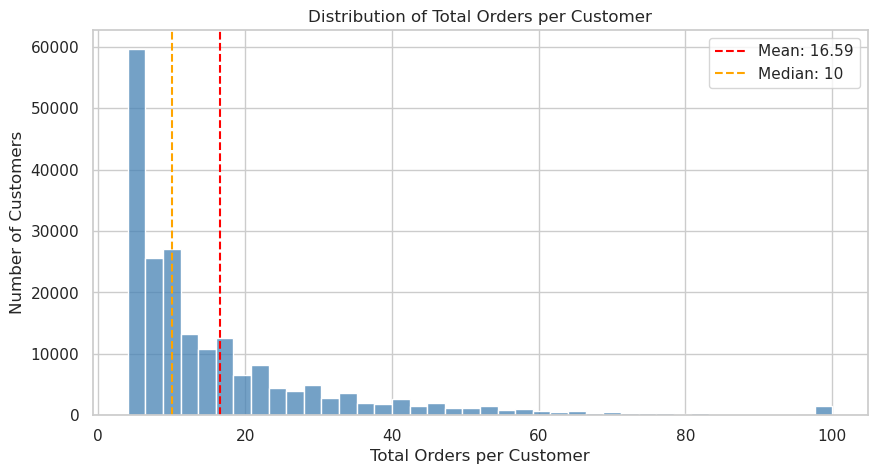

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_orders,
    bins=40,
    color="steelblue"
)

plt.axvline(
    customer_orders.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {customer_orders.mean():.2f}"
)

plt.axvline(
    customer_orders.median(),
    color="orange",
    linestyle="--",
    label=f"Median: {customer_orders.median():.0f}"
)

plt.title("Distribution of Total Orders per Customer")
plt.xlabel("Total Orders per Customer")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

### Findings

- Customers placed an average of 16.59 orders.
- The median customer placed 10 orders.
- Most customers had relatively few recorded orders, generally fewer than 20.
- A smaller group placed a much higher number of orders.
- The mean is higher than the median because high-order customers pull the average upward.
- This indicates that customer engagement differs considerably across the customer base.

### Business implications

Instacart could separate customers into lower-frequency and higher-frequency groups.
Frequent customers may be suitable for loyalty rewards, while less frequent customers
could receive re-engagement promotions.

EDA 3B: Average days between orders

This better represents how regularly customers return

In [24]:
days_between_orders = (
    dim_user["average_days_between_orders"]
    .dropna()
)

print("Customers analysed:", f"{len(days_between_orders):,}")
print(
    "Average days between orders:",
    round(days_between_orders.mean(), 2)
)
print(
    "Median days between orders:",
    round(days_between_orders.median(), 2)
)
print(
    "Minimum average gap:",
    round(days_between_orders.min(), 2)
)
print(
    "Maximum average gap:",
    round(days_between_orders.max(), 2)
)

Customers analysed: 206,209
Average days between orders: 15.45
Median days between orders: 15.0
Minimum average gap: 0.0
Maximum average gap: 30.0


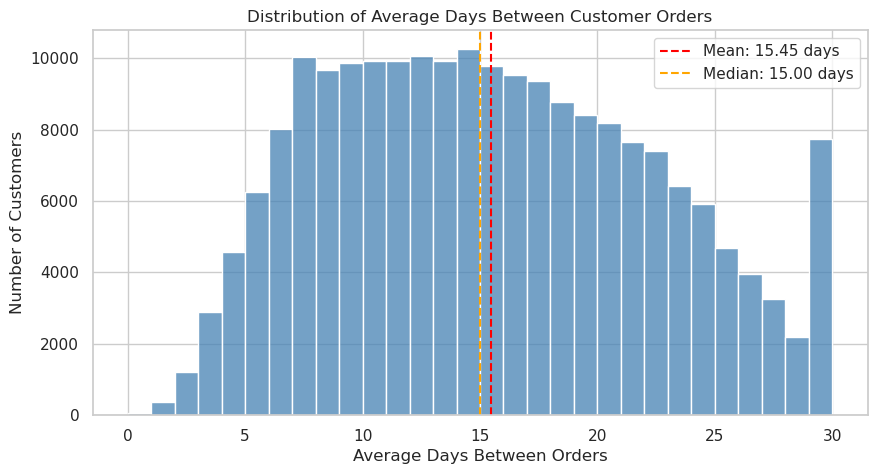

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    days_between_orders,
    bins=30,
    color="steelblue"
)

plt.axvline(
    days_between_orders.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {days_between_orders.mean():.2f} days"
)

plt.axvline(
    days_between_orders.median(),
    color="orange",
    linestyle="--",
    label=f"Median: {days_between_orders.median():.2f} days"
)

plt.title("Distribution of Average Days Between Customer Orders")
plt.xlabel("Average Days Between Orders")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

### Findings

- The mean customer order gap was 15.45 days.
- The median customer order gap was 15 days.
- Because the mean and median are very similar, the distribution is relatively balanced.
- Many customers had an average ordering interval of approximately 7 to 22 days.
- This suggests that a typical customer returned approximately every two weeks.
- The higher bar around 30 days must be interpreted carefully because the original
  `days_since_prior_order` field is capped at 30 days.

### Business implications

Instacart could send personalised reminders or promotions approximately 14 to 15 days
after a customer's previous order. Customers who have not returned after approximately
20 days could receive re-engagement offers.

The result can also support inventory planning around a two-week customer purchasing cycle.


#### 4: Customer reorder behaviour

In [26]:
customer_reorder = (
    dim_user["customer_reorder_rate"]
    .dropna()
)

print("Customers analysed:", f"{len(customer_reorder):,}")
print("Average customer reorder rate:", f"{customer_reorder.mean():.2%}")
print("Median customer reorder rate:", f"{customer_reorder.median():.2%}")
print("Minimum reorder rate:", f"{customer_reorder.min():.2%}")
print("Maximum reorder rate:", f"{customer_reorder.max():.2%}")

Customers analysed: 206,209
Average customer reorder rate: 44.43%
Median customer reorder rate: 44.26%
Minimum reorder rate: 0.00%
Maximum reorder rate: 98.96%


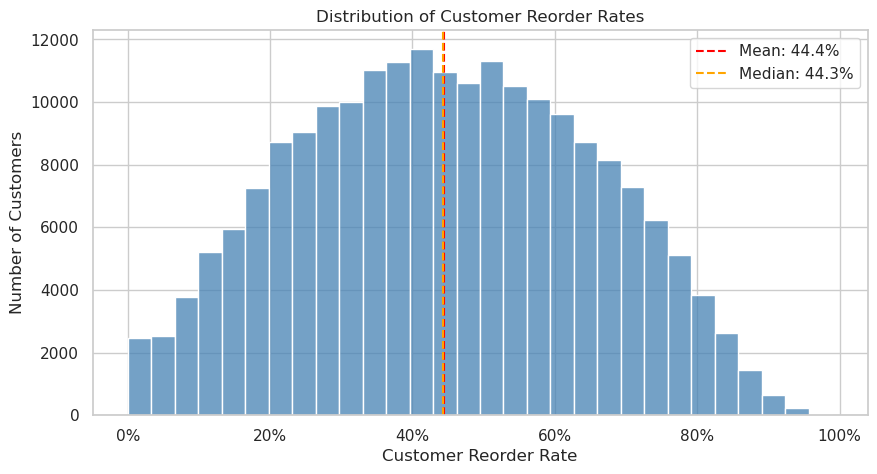

In [27]:
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(10, 5))

ax = sns.histplot(
    customer_reorder,
    bins=30,
    color="steelblue"
)

plt.axvline(
    customer_reorder.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {customer_reorder.mean():.1%}"
)

plt.axvline(
    customer_reorder.median(),
    color="orange",
    linestyle="--",
    label=f"Median: {customer_reorder.median():.1%}"
)

ax.xaxis.set_major_formatter(PercentFormatter(1))

plt.title("Distribution of Customer Reorder Rates")
plt.xlabel("Customer Reorder Rate")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

### Findings

- The average customer reorder rate was 44.4%.
- The median customer reorder rate was 44.3%.
- The similar mean and median indicate that the distribution is reasonably balanced.
- A typical customer repurchased approximately 44% of previously purchased items.
- Most customers had a mixture of repeated products and newly selected products.
- Relatively few customers had extremely low or extremely high reorder rates.

### Business implications

Customers with high reorder rates may respond well to replenishment reminders,
personalised recommendations and repeat-order shortcuts.

Customers with lower reorder rates may be more interested in product discovery,
new-product recommendations and broader promotions.


## 5. Customer Segmentation

**Business question:** What customer purchasing segments exist?

Customers are divided according to their observed number of orders and product
reorder rate. Median values are used as data-driven thresholds.

#### 1: Create the segment

In [29]:
import numpy as np

dim_user_eda = dim_user.copy()

order_threshold = dim_user_eda["total_orders"].median()
reorder_threshold = dim_user_eda["customer_reorder_rate"].median()

print("Order threshold:", order_threshold)
print("Reorder-rate threshold:", f"{reorder_threshold:.1%}")

Order threshold: 10.0
Reorder-rate threshold: 44.3%


#### Segment meanings:

Frequent Repeat Customers: more orders and more repeated products
Frequent Variety Customers: more orders but greater product variety
Occasional Repeat Customers: fewer orders but often purchase familiar products
Occasional Variety Customers: fewer orders and lower product repetition

In [30]:
conditions = [
    (
        (dim_user_eda["total_orders"] >= order_threshold) &
        (dim_user_eda["customer_reorder_rate"] >= reorder_threshold)
    ),
    (
        (dim_user_eda["total_orders"] >= order_threshold) &
        (dim_user_eda["customer_reorder_rate"] < reorder_threshold)
    ),
    (
        (dim_user_eda["total_orders"] < order_threshold) &
        (dim_user_eda["customer_reorder_rate"] >= reorder_threshold)
    )
]

segments = [
    "Frequent Repeat Customers",
    "Frequent Variety Customers",
    "Occasional Repeat Customers"
]

dim_user_eda["customer_segment"] = np.select(
    conditions,
    segments,
    default="Occasional Variety Customers"
)

dim_user_eda[
    ["user_id", "total_orders", "customer_reorder_rate", "customer_segment"]
].head()

,user_id,total_orders,customer_reorder_rate,customer_segment
0,1,11,0.728571,Frequent Repeat Customers
1,2,15,0.464602,Frequent Repeat Customers
2,3,13,0.625000,Frequent Repeat Customers
3,4,6,0.055556,Occasional Variety Customers
4,5,5,0.391304,Occasional Variety Customers


#### 2: Summarise the segments

In [31]:
segment_summary = (
    dim_user_eda
    .groupby("customer_segment")
    .agg(
        customer_count=("user_id", "count"),
        average_orders=("total_orders", "mean"),
        average_reorder_rate=("customer_reorder_rate", "mean"),
        average_basket_size=("average_basket_size", "mean"),
        average_order_gap=("average_days_between_orders", "mean")
    )
    .reset_index()
)

segment_summary["customer_percentage"] = (
    segment_summary["customer_count"] /
    segment_summary["customer_count"].sum() * 100
)

display(segment_summary.round(2))

,customer_segment,customer_count,average_orders,average_reorder_rate,average_basket_size,average_order_gap,customer_percentage
0,Frequent Repeat Customers,83265,29.19,0.63,10.61,11.53,40.38
1,Frequent Variety Customers,27463,15.20,0.34,8.85,14.76,13.32
2,Occasional Repeat Customers,19850,6.85,0.54,9.97,18.16,9.63
3,Occasional Variety Customers,75631,5.78,0.25,9.71,19.30,36.68


##### 3: Draw the segment chart

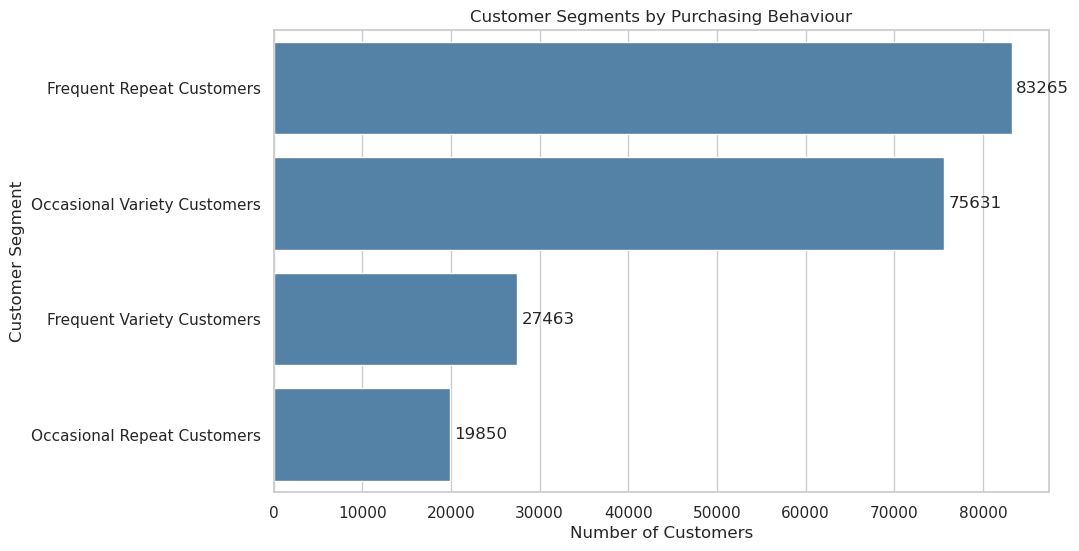

In [32]:
segment_summary = segment_summary.sort_values(
    "customer_count",
    ascending=False
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=segment_summary,
    y="customer_segment",
    x="customer_count",
    color="steelblue"
)

plt.title("Customer Segments by Purchasing Behaviour")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.ticklabel_format(style="plain", axis="x")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.show()

### Findings

- Frequent Repeat Customers formed the largest segment: 83,265 customers (40.4%).
- Occasional Variety Customers were the second-largest segment: 75,631 customers (36.7%).
- Frequent Variety Customers accounted for 27,463 customers (13.3%).
- Occasional Repeat Customers were the smallest segment: 19,850 customers (9.6%).
- The two largest segments represent contrasting behaviour: frequent repeat
  purchasing and occasional product exploration.

### Business implications

- Frequent Repeat Customers: offer loyalty rewards, subscriptions and reorder shortcuts.
- Occasional Variety Customers: use re-engagement promotions and new-product recommendations.
- Frequent Variety Customers: promote discovery bundles and cross-selling offers.
- Occasional Repeat Customers: send replenishment reminders for familiar products.

### 6: Most popular products

fact_order_item.zip is very large, so do not load all 33 million rows into memory. Read it in chunks and calculate product totals.

##### Step 1: Aggregate product activity

This single process calculates both purchase counts and reordered counts for later analyses.


In [33]:
purchase_counts = pd.Series(dtype="int64")
reordered_counts = pd.Series(dtype="int64")

chunk_reader = pd.read_csv(
    "../Dataset/fact_order_item.zip",
    compression="zip",
    usecols=["product_id", "reordered"],
    chunksize=1_000_000
)

for chunk_number, chunk in enumerate(chunk_reader, start=1):

    chunk_purchases = chunk["product_id"].value_counts()

    chunk_reorders = (
        chunk.groupby("product_id")["reordered"]
        .sum()
    )

    purchase_counts = purchase_counts.add(
        chunk_purchases,
        fill_value=0
    )

    reordered_counts = reordered_counts.add(
        chunk_reorders,
        fill_value=0
    )

    print(f"Processed chunk {chunk_number}")

Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed chunk 7
Processed chunk 8
Processed chunk 9
Processed chunk 10
Processed chunk 11
Processed chunk 12
Processed chunk 13
Processed chunk 14
Processed chunk 15
Processed chunk 16
Processed chunk 17
Processed chunk 18
Processed chunk 19
Processed chunk 20
Processed chunk 21
Processed chunk 22
Processed chunk 23
Processed chunk 24
Processed chunk 25
Processed chunk 26
Processed chunk 27
Processed chunk 28
Processed chunk 29
Processed chunk 30
Processed chunk 31
Processed chunk 32
Processed chunk 33
Processed chunk 34


##### Step 2: Create the product summary

In [34]:
product_metrics = pd.DataFrame({
    "product_id": purchase_counts.index.astype("int64"),
    "purchase_count": purchase_counts.values.astype("int64")
})

product_metrics["reordered_count"] = (
    reordered_counts
    .reindex(product_metrics["product_id"], fill_value=0)
    .values
    .astype("int64")
)

product_metrics["product_reorder_rate"] = (
    product_metrics["reordered_count"] /
    product_metrics["purchase_count"]
)

product_metrics = product_metrics.merge(
    dim_product,
    on="product_id",
    how="left"
)

print("Product summary shape:", product_metrics.shape)
display(product_metrics.head())

Product summary shape: (49685, 9)


,product_id,purchase_count,reordered_count,product_reorder_rate,product_name,aisle_id,aisle,department_id,department
0,1,1928,1185,0.614627,Chocolate Sandwich Cookies,61,cookies cakes,19,snacks
1,2,94,13,0.138298,All-Seasons Salt,104,spices seasonings,13,pantry
2,3,283,209,0.738516,Robust Golden Unsweetened Oolong Tea,94,tea,7,beverages
3,4,351,161,0.458689,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,frozen meals,1,frozen
4,5,16,10,0.625000,Green Chile Anytime Sauce,5,marinades meat preparation,13,pantry


##### Step 3: Find the top 10 products

In [35]:
top_products = (
    product_metrics
    .nlargest(10, "purchase_count")
    [
        [
            "product_id",
            "product_name",
            "department",
            "purchase_count"
        ]
    ]
)

display(top_products)

,product_id,product_name,department,purchase_count
24849,24852,Banana,produce,491291
13173,13176,Bag of Organic Bananas,produce,394930
21134,21137,Organic Strawberries,produce,275577
21900,21903,Organic Baby Spinach,produce,251705
47205,47209,Organic Hass Avocado,produce,220877
47762,47766,Organic Avocado,produce,184224
47622,47626,Large Lemon,produce,160792
16794,16797,Strawberries,produce,149445
26206,26209,Limes,produce,146660
27842,27845,Organic Whole Milk,dairy eggs,142813


##### Step 4: Draw a horizontal bar chart

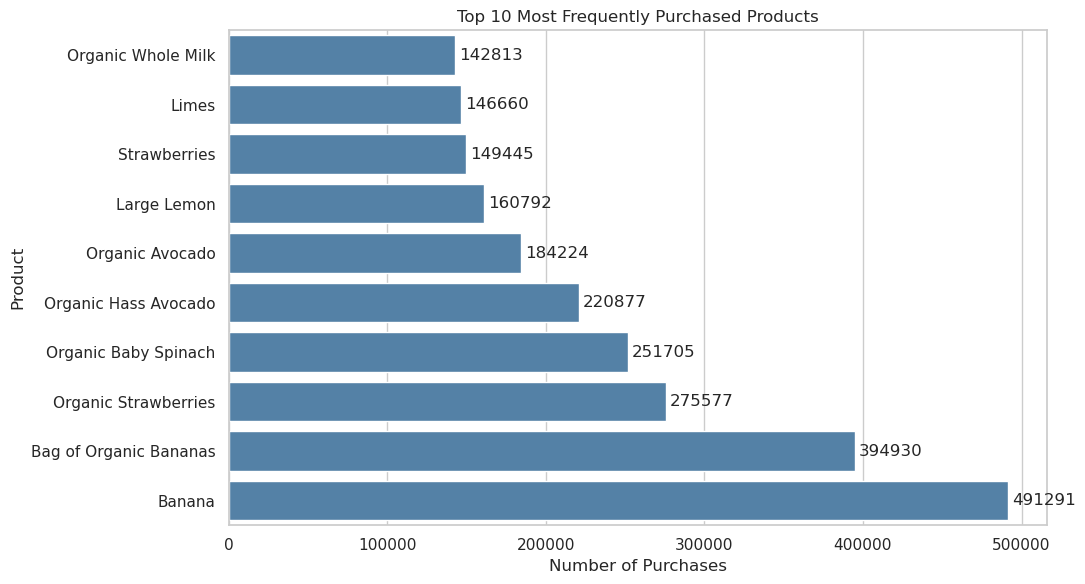

In [36]:
top_products_chart = top_products.sort_values(
    "purchase_count",
    ascending=True
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=top_products_chart,
    y="product_name",
    x="purchase_count",
    color="steelblue"
)

plt.title("Top 10 Most Frequently Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")
plt.ticklabel_format(style="plain", axis="x")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

### Findings

- Banana was the most frequently purchased product, appearing 491,291 times.
- Bag of Organic Bananas ranked second, with 394,930 purchases.
- Organic Strawberries ranked third, with 275,577 purchases.
- Fresh produce dominated the ranking: nine of the top ten products were fruits or vegetables.
- Several organic products appeared in the top ten, indicating strong observed demand
  for organic grocery products.
- Organic Whole Milk was the only non-produce product in the top ten.

### Business implications

Instacart should maintain sufficient inventory and delivery capacity for high-demand
fresh products, especially bananas, strawberries, avocados and spinach.

Popular products can also be used as starting points for cross-selling recommendations,
such as recommending complementary products alongside bananas or avocados.



#### EDA 7: Which departments receive the most purchases?

Use a horizontal bar chart because departments are categories being ranked.

##### Step 1: Calculate department totals

In [37]:
department_summary = (
    product_metrics
    .groupby("department", as_index=False)
    .agg(
        purchase_count=("purchase_count", "sum")
    )
    .sort_values(
        "purchase_count",
        ascending=False
    )
)

department_summary["purchase_percentage"] = (
    department_summary["purchase_count"] /
    department_summary["purchase_count"].sum() * 100
)

display(department_summary.round(2))

,department,purchase_count,purchase_percentage
19,produce,9888378,29.24
7,dairy eggs,5631067,16.65
20,snacks,3006412,8.89
3,beverages,2804175,8.29
10,frozen,2336858,6.91
16,pantry,1956819,5.79
2,bakery,1225181,3.62
6,canned goods,1114857,3.30
8,deli,1095540,3.24
9,dry goods pasta,905340,2.68


##### Step 2: Select the top 10 departments

In [38]:
top_departments = (
    department_summary
    .nlargest(10, "purchase_count")
    .sort_values("purchase_count", ascending=True)
)

display(top_departments)

,department,purchase_count,purchase_percentage
9,dry goods pasta,905340,2.677007
8,deli,1095540,3.239411
6,canned goods,1114857,3.296530
2,bakery,1225181,3.622748
16,pantry,1956819,5.786135
10,frozen,2336858,6.909875
3,beverages,2804175,8.291689
20,snacks,3006412,8.889685
7,dairy eggs,5631067,16.650550
19,produce,9888378,29.239028


##### Step 2: Select the top 10 departments

In [39]:
top_departments = (
    department_summary
    .nlargest(10, "purchase_count")
    .sort_values("purchase_count", ascending=True)
)

display(top_departments)

,department,purchase_count,purchase_percentage
9,dry goods pasta,905340,2.677007
8,deli,1095540,3.239411
6,canned goods,1114857,3.296530
2,bakery,1225181,3.622748
16,pantry,1956819,5.786135
10,frozen,2336858,6.909875
3,beverages,2804175,8.291689
20,snacks,3006412,8.889685
7,dairy eggs,5631067,16.650550
19,produce,9888378,29.239028


In [40]:
import plotly.express as px

fig = px.treemap(
    department_summary,
    path=[
        px.Constant("All Departments"),
        "department"
    ],
    values="purchase_count",
    color="purchase_count",
    color_continuous_scale="Blues",
    hover_data={
        "purchase_count": ":,",
        "purchase_percentage": ":.1f"
    },
    title="Distribution of Purchases by Department"
)

fig.update_traces(
    textinfo="label+value+percent root"
)

fig.update_layout(
    margin=dict(t=50, l=10, r=10, b=10)
)

fig.show()

### Findings

- Produce was the largest department, with 9,888,378 purchases, representing 29%.
- Dairy and eggs ranked second, with 5,631,067 purchases, representing 17%.
- Produce and dairy/eggs together accounted for approximately 46% of all purchases.
- Snacks represented 9%, beverages 8%, and frozen products 7%.
- The five largest departments accounted for approximately 70% of purchase activity.
- This supports the earlier product analysis, where fresh produce dominated the
  most frequently purchased products.

### Business implications

Instacart should prioritise inventory availability, picking capacity and delivery
handling for produce and dairy/egg products.

The concentration in produce and dairy also creates cross-selling opportunities,
such as recommending dairy products alongside frequently purchased fresh produce.


#### EDA 8: Products with high reorder rates

To avoid another bar chart, use a lollipop chart.

Products with very few purchases can produce misleading reorder rates. Therefore, only include products purchased at least 1,000 times.

In [42]:
eligible_products = product_metrics[
    product_metrics["purchase_count"] >= 1000
].copy()

top_reordered_products = (
    eligible_products
    .nlargest(10, "product_reorder_rate")
    .sort_values("product_reorder_rate", ascending=True)
)

top_reordered_products["reorder_rate_percentage"] = (
    top_reordered_products["product_reorder_rate"] * 100
)

display(
    top_reordered_products[
        [
            "product_name",
            "department",
            "purchase_count",
            "reordered_count",
            "reorder_rate_percentage"
        ]
    ].round(2)
)

,product_name,department,purchase_count,reordered_count,reorder_rate_percentage
39177,Organic Lowfat 1% Milk,dairy eggs,15352,12914,84.12
24849,Banana,produce,491291,415166,84.51
34194,Goat Milk,dairy eggs,5353,4551,85.02
38686,Organic Reduced Fat Milk,dairy eggs,36869,31394,85.15
29444,"Milk, Organic, Vitamin D",dairy eggs,20770,17753,85.47
47227,Ultra-Purified Water,beverages,1524,1306,85.70
5512,Organic Homogenized Whole Milk,dairy eggs,4095,3514,85.81
43391,Organic Lactose Free Whole Milk,dairy eggs,8742,7511,85.92
45501,Whole Organic Omega 3 Milk,dairy eggs,9410,8091,85.98
9289,Half And Half Ultra Pasteurized,dairy eggs,2995,2580,86.14


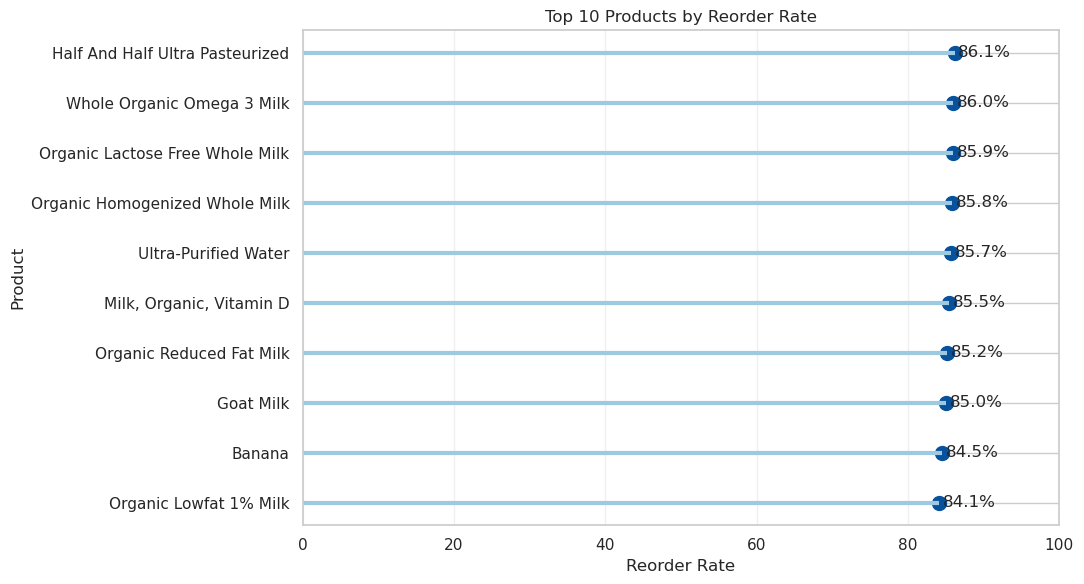

In [43]:
import numpy as np

y_positions = np.arange(len(top_reordered_products))

plt.figure(figsize=(11, 6))

plt.hlines(
    y=y_positions,
    xmin=0,
    xmax=top_reordered_products["reorder_rate_percentage"],
    color="#9ecae1",
    linewidth=3
)

plt.scatter(
    top_reordered_products["reorder_rate_percentage"],
    y_positions,
    color="#08519c",
    s=100
)

plt.yticks(
    y_positions,
    top_reordered_products["product_name"]
)

for y, rate in zip(
    y_positions,
    top_reordered_products["reorder_rate_percentage"]
):
    plt.text(
        rate + 0.5,
        y,
        f"{rate:.1f}%",
        va="center"
    )

plt.title("Top 10 Products by Reorder Rate")
plt.xlabel("Reorder Rate")
plt.ylabel("Product")
plt.xlim(0, 100)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Findings

- Half and Half Ultra Pasteurized had the highest observed reorder rate at 86.1%.
- The top ten products had very similar reorder rates, ranging from 84.1% to 86.1%.
- Milk products dominated the ranking, together with water and bananas.
- These products are common household staples that customers may need to replenish regularly.
- The narrow two-percentage-point difference means the exact ranking should not be overemphasised.

### Business implications

Instacart could provide reorder reminders, subscription options and repeat-order
shortcuts for frequently replenished products such as milk and water.


#### Final EDA: Products purchased together

Because fact_order_item.zip is large, count pairs in chunks. To keep processing manageable, analyse combinations among the 50 most frequently purchased products.

##### Step 1: Select the 50 popular products

In [45]:
top_50_products = product_metrics.nlargest(
    50,
    "purchase_count"
)

top_50_ids = set(
    top_50_products["product_id"]
)

print("Products included:", len(top_50_ids))


Products included: 50


#### Step 2: Count product pairs safely

The carryover prevents an order divided between two chunks from being counted incorrectly.

In [46]:
from collections import Counter
from itertools import combinations

pair_counts = Counter()

carryover = pd.DataFrame(
    columns=["order_id", "product_id"]
)

chunk_reader = pd.read_csv(
    "../Dataset/fact_order_item.zip",
    compression="zip",
    usecols=["order_id", "product_id"],
    chunksize=1_000_000
)

for chunk_number, chunk in enumerate(chunk_reader, start=1):

    working_chunk = pd.concat(
        [carryover, chunk],
        ignore_index=True
    )

    last_order_id = working_chunk["order_id"].iloc[-1]

    carryover = working_chunk[
        working_chunk["order_id"] == last_order_id
    ].copy()

    complete_orders = working_chunk[
        working_chunk["order_id"] != last_order_id
    ]

    popular_items = complete_orders[
        complete_orders["product_id"].isin(top_50_ids)
    ]

    products_by_order = (
        popular_items
        .groupby("order_id")["product_id"]
        .unique()
    )

    for products in products_by_order:

        products = sorted(products)

        if len(products) >= 2:
            pair_counts.update(
                combinations(products, 2)
            )

    print(f"Processed chunk {chunk_number}")

Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed chunk 7
Processed chunk 8
Processed chunk 9
Processed chunk 10
Processed chunk 11
Processed chunk 12
Processed chunk 13
Processed chunk 14
Processed chunk 15
Processed chunk 16
Processed chunk 17
Processed chunk 18
Processed chunk 19
Processed chunk 20
Processed chunk 21
Processed chunk 22
Processed chunk 23
Processed chunk 24
Processed chunk 25
Processed chunk 26
Processed chunk 27
Processed chunk 28
Processed chunk 29
Processed chunk 30
Processed chunk 31
Processed chunk 32
Processed chunk 33
Processed chunk 34


#### Process the final carried-over order:

In [47]:
final_items = carryover[
    carryover["product_id"].isin(top_50_ids)
]

final_products = sorted(
    final_items["product_id"].unique()
)

if len(final_products) >= 2:
    pair_counts.update(
        combinations(final_products, 2)
    )

print("Unique product pairs:", len(pair_counts))

Unique product pairs: 1225


#### Step 3: Create the product-pair table

In [48]:
product_name_lookup = (
    dim_product
    .set_index("product_id")["product_name"]
    .to_dict()
)

product_pairs = pd.DataFrame(
    [
        {
            "product_a_id": product_a,
            "product_b_id": product_b,
            "pair_order_count": pair_count
        }
        for (product_a, product_b), pair_count
        in pair_counts.items()
    ]
)

product_pairs["product_a"] = (
    product_pairs["product_a_id"]
    .map(product_name_lookup)
)

product_pairs["product_b"] = (
    product_pairs["product_b_id"]
    .map(product_name_lookup)
)

top_product_pairs = (
    product_pairs
    .nlargest(10, "pair_order_count")
    [
        [
            "product_a",
            "product_b",
            "pair_order_count"
        ]
    ]
)

display(top_product_pairs)

,product_a,product_b,pair_order_count
2,Bag of Organic Bananas,Organic Hass Avocado,64761
277,Bag of Organic Bananas,Organic Strawberries,64702
9,Organic Strawberries,Banana,58330
14,Banana,Organic Avocado,55611
28,Organic Baby Spinach,Banana,53395
267,Bag of Organic Bananas,Organic Baby Spinach,52608
258,Strawberries,Banana,43180
70,Banana,Large Lemon,43038
103,Organic Strawberries,Organic Hass Avocado,42333
1,Bag of Organic Bananas,Organic Raspberries,42283


##### Step 4: Create an association heatmap

In [49]:
heatmap_products = (
    product_metrics
    .nlargest(10, "purchase_count")
    [
        ["product_id", "product_name"]
    ]
)

heatmap_ids = heatmap_products["product_id"].tolist()
heatmap_names = heatmap_products["product_name"].tolist()

pair_matrix = pd.DataFrame(
    0,
    index=heatmap_names,
    columns=heatmap_names,
    dtype=int
)

for i, product_a_id in enumerate(heatmap_ids):

    for j, product_b_id in enumerate(heatmap_ids):

        if product_a_id == product_b_id:
            continue

        pair_key = tuple(
            sorted([product_a_id, product_b_id])
        )

        pair_matrix.iloc[i, j] = pair_counts.get(
            pair_key,
            0
        )

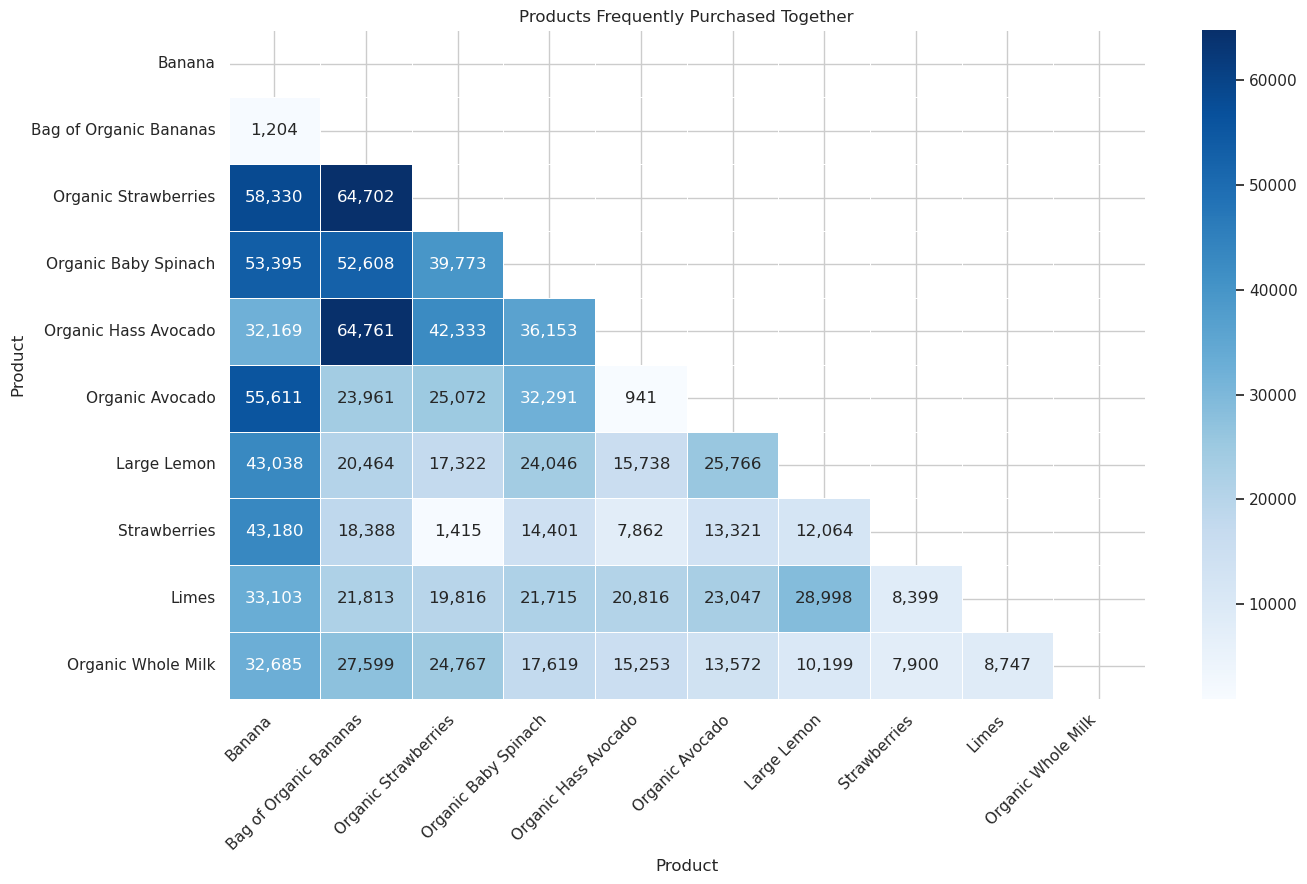

In [50]:
annotations = pair_matrix.applymap(
    lambda value: f"{value:,}" if value > 0 else ""
)

mask = np.triu(
    np.ones_like(pair_matrix, dtype=bool)
)

plt.figure(figsize=(14, 9))

sns.heatmap(
    pair_matrix,
    mask=mask,
    annot=annotations,
    fmt="",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Products Frequently Purchased Together")
plt.xlabel("Product")
plt.ylabel("Product")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Findings

- Bag of Organic Bananas and Organic Hass Avocado were purchased together in
  64,761 orders, the highest co-purchase count shown.
- Bag of Organic Bananas and Organic Strawberries appeared together in 64,702 orders.
- Banana and Organic Strawberries appeared together in 58,330 orders.
- Banana and Organic Avocado appeared together in 55,611 orders.
- Fresh produce dominates the frequent product combinations.

Some similar product alternatives had very low co-purchase counts:

- Banana and Bag of Organic Bananas: 1,204 orders
- Organic Hass Avocado and Organic Avocado: 941 orders
- Strawberries and Organic Strawberries: 1,415 orders

These low counts suggest that customers may choose one product variant instead of
purchasing both, although lift is required to confirm this relationship.

### Business implications

Frequently combined products could be displayed together in recommendations,
recipe suggestions or promotional bundles.

Similar alternatives should be recommended as substitutes rather than bundled together.

In [55]:
from pathlib import Path
import pandas as pd

# EDA.ipynb is inside Notebook, so ".." returns to the project root.
dashboard_data_path = Path("../Dashboard/data")

dashboard_data_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Saving to:", dashboard_data_path.resolve())

Saving to: /home/yoke/Market-Basket-Analysis/Dashboard/data


In [56]:
dashboard_kpis = pd.DataFrame([
    {
        "total_orders": fact_order["order_id"].nunique(),
        "total_customers": dim_user["user_id"].nunique(),
        "total_products": dim_product["product_id"].nunique(),
        "average_basket_size": fact_order["basket_size"].mean(),
        "average_customer_reorder_rate":
            dim_user["customer_reorder_rate"].mean(),
        "average_days_between_orders":
            dim_user["average_days_between_orders"].mean()
    }
])

In [57]:
dashboard_order_time = (
    fact_order[
        ["order_id", "slot_key"]
    ]
    .merge(
        dim_order_slot,
        on="slot_key",
        how="left"
    )
    .groupby(
        ["order_dow", "order_hour_of_day"],
        as_index=False
    )
    .agg(
        order_count=("order_id", "count")
    )
)

In [58]:
dashboard_basket_distribution = (
    fact_order["basket_size"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis("basket_size")
    .reset_index(name="order_count")
)

In [62]:
import numpy as np

# Create a working copy
customer_eda = dim_user.copy()

# Calculate the two median thresholds
order_threshold = customer_eda["total_orders"].median()

reorder_threshold = (
    customer_eda["customer_reorder_rate"].median()
)

# Define the segment conditions
conditions = [
    # More orders and higher reorder rate
    (
        (customer_eda["total_orders"] >= order_threshold) &
        (
            customer_eda["customer_reorder_rate"]
            >= reorder_threshold
        )
    ),

    # More orders but lower reorder rate
    (
        (customer_eda["total_orders"] >= order_threshold) &
        (
            customer_eda["customer_reorder_rate"]
            < reorder_threshold
        )
    ),

    # Fewer orders but higher reorder rate
    (
        (customer_eda["total_orders"] < order_threshold) &
        (
            customer_eda["customer_reorder_rate"]
            >= reorder_threshold
        )
    )
]

segment_names = [
    "Frequent Repeat Customers",
    "Frequent Variety Customers",
    "Occasional Repeat Customers"
]

# Assign the segment
customer_eda["customer_segment"] = np.select(
    conditions,
    segment_names,
    default="Occasional Variety Customers"
)

print("Order threshold:", order_threshold)
print("Reorder-rate threshold:", f"{reorder_threshold:.1%}")

print("\nCustomer segments:")

print(
    customer_eda["customer_segment"]
    .value_counts()
)

print("\nTotal customers:", f"{len(customer_eda):,}")

Order threshold: 10.0
Reorder-rate threshold: 44.3%

Customer segments:
Frequent Repeat Customers       83265
Occasional Variety Customers    75631
Frequent Variety Customers      27463
Occasional Repeat Customers     19850
Name: customer_segment, dtype: int64

Total customers: 206,209


In [63]:
dashboard_customer_segments = (
    customer_eda
    .groupby("customer_segment")
    .agg(
        customer_count=("user_id", "count"),
        average_orders=("total_orders", "mean"),
        average_basket_size=("average_basket_size", "mean"),
        average_reorder_rate=("customer_reorder_rate", "mean"),
        average_order_gap=("average_days_between_orders", "mean")
    )
    .reset_index()
)

dashboard_customer_segments["customer_percentage"] = (
    dashboard_customer_segments["customer_count"] /
    dashboard_customer_segments["customer_count"].sum() * 100
)

display(dashboard_customer_segments.round(2))

,customer_segment,customer_count,average_orders,average_basket_size,average_reorder_rate,average_order_gap,customer_percentage
0,Frequent Repeat Customers,83265,29.19,10.61,0.63,11.53,40.38
1,Frequent Variety Customers,27463,15.20,8.85,0.34,14.76,13.32
2,Occasional Repeat Customers,19850,6.85,9.97,0.54,18.16,9.63
3,Occasional Variety Customers,75631,5.78,9.71,0.25,19.30,36.68


In [64]:
dashboard_customer_segments = (
    customer_eda
    .groupby("customer_segment")
    .agg(
        customer_count=("user_id", "count"),
        average_orders=("total_orders", "mean"),
        average_basket_size=("average_basket_size", "mean"),
        average_reorder_rate=("customer_reorder_rate", "mean"),
        average_order_gap=("average_days_between_orders", "mean")
    )
    .reset_index()
)

dashboard_customer_segments["customer_percentage"] = (
    dashboard_customer_segments["customer_count"] /
    dashboard_customer_segments["customer_count"].sum()
    * 100
)

display(
    dashboard_customer_segments.round(2)
)

,customer_segment,customer_count,average_orders,average_basket_size,average_reorder_rate,average_order_gap,customer_percentage
0,Frequent Repeat Customers,83265,29.19,10.61,0.63,11.53,40.38
1,Frequent Variety Customers,27463,15.20,8.85,0.34,14.76,13.32
2,Occasional Repeat Customers,19850,6.85,9.97,0.54,18.16,9.63
3,Occasional Variety Customers,75631,5.78,9.71,0.25,19.30,36.68


In [65]:
print(
    "Total customers:",
    f"{dashboard_customer_segments['customer_count'].sum():,}"
)

print(
    "Number of segments:",
    len(dashboard_customer_segments)
)

Total customers: 206,209
Number of segments: 4


In [67]:
dashboard_kpis = pd.DataFrame([
    {
        "total_orders":
            fact_order["order_id"].nunique(),

        "total_customers":
            dim_user["user_id"].nunique(),

        "total_products":
            dim_product["product_id"].nunique(),

        "average_basket_size":
            fact_order["basket_size"].mean(),

        "average_customer_reorder_rate":
            dim_user["customer_reorder_rate"].mean(),

        "average_days_between_orders":
            dim_user["average_days_between_orders"].mean()
    }
])

display(
    dashboard_kpis.round(2)
)

,total_orders,total_customers,total_products,average_basket_size,average_customer_reorder_rate,average_days_between_orders
0,3421083,206209,49688,10.11,0.44,15.45


In [68]:
kpi = dashboard_kpis.iloc[0]

print("Total orders:", f"{kpi['total_orders']:,.0f}")
print("Total customers:", f"{kpi['total_customers']:,.0f}")
print("Total products:", f"{kpi['total_products']:,.0f}")

print(
    "Average basket size:",
    f"{kpi['average_basket_size']:.2f}"
)

print(
    "Average customer reorder rate:",
    f"{kpi['average_customer_reorder_rate']:.1%}"
)

print(
    "Average days between orders:",
    f"{kpi['average_days_between_orders']:.2f}"
)

Total orders: 3,421,083
Total customers: 206,209
Total products: 49,688
Average basket size: 10.11
Average customer reorder rate: 44.4%
Average days between orders: 15.45


In [69]:
dashboard_order_time = (
    fact_order[
        [
            "order_id",
            "slot_key"
        ]
    ]
    .merge(
        dim_order_slot,
        on="slot_key",
        how="left"
    )
    .groupby(
        [
            "order_dow",
            "order_hour_of_day"
        ],
        as_index=False
    )
    .agg(
        order_count=("order_id", "count")
    )
)

display(
    dashboard_order_time.head(10)
)

,order_dow,order_hour_of_day,order_count
0,0,0,3936
1,0,1,2398
2,0,2,1409
3,0,3,963
4,0,4,813
5,0,5,1168
6,0,6,3329
7,0,7,12410
8,0,8,28108
9,0,9,40798


In [70]:
print(
    "Number of day-hour combinations:",
    len(dashboard_order_time)
)

print(
    "Total orders:",
    f"{dashboard_order_time['order_count'].sum():,}"
)

print(
    "Missing values:",
    dashboard_order_time.isna().sum().sum()
)

Number of day-hour combinations: 168
Total orders: 3,421,083
Missing values: 0


In [71]:
dashboard_basket_distribution = (
    fact_order["basket_size"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis("basket_size")
    .reset_index(name="order_count")
)

display(
    dashboard_basket_distribution.head(10)
)

,basket_size,order_count
0,1,163593
1,2,194361
2,3,215060
3,4,230299
4,5,237225
5,6,236383
6,7,228547
7,8,211357
8,9,191564
9,10,172103


In [72]:
print(
    "Number of basket-size categories:",
    len(dashboard_basket_distribution)
)

print(
    "Orders with known basket size:",
    f"{dashboard_basket_distribution['order_count'].sum():,}"
)

print(
    "Smallest basket:",
    dashboard_basket_distribution["basket_size"].min()
)

print(
    "Largest basket:",
    dashboard_basket_distribution["basket_size"].max()
)

print(
    "Missing values:",
    dashboard_basket_distribution.isna().sum().sum()
)

Number of basket-size categories: 113
Orders with known basket size: 3,346,083
Smallest basket: 1
Largest basket: 145
Missing values: 0


In [73]:
dashboard_product_metrics = product_metrics[
    [
        "product_id",
        "product_name",
        "aisle",
        "department",
        "purchase_count",
        "reordered_count",
        "product_reorder_rate"
    ]
].copy()

display(
    dashboard_product_metrics.head(10)
)

,product_id,product_name,aisle,department,purchase_count,reordered_count,product_reorder_rate
0,1,Chocolate Sandwich Cookies,cookies cakes,snacks,1928,1185,0.614627
1,2,All-Seasons Salt,spices seasonings,pantry,94,13,0.138298
2,3,Robust Golden Unsweetened Oolong Tea,tea,beverages,283,209,0.738516
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,frozen meals,frozen,351,161,0.458689
4,5,Green Chile Anytime Sauce,marinades meat preparation,pantry,16,10,0.625000
5,6,Dry Nose Oil,cold flu allergy,personal care,8,3,0.375000
6,7,Pure Coconut Water With Orange,juice nectars,beverages,31,13,0.419355
7,8,Cut Russet Potatoes Steam N' Mash,frozen produce,frozen,178,90,0.505618
8,9,Light Strawberry Blueberry Yogurt,yogurt,dairy eggs,161,84,0.521739
9,10,Sparkling Orange Juice & Prickly Pear Beverage,water seltzer sparkling water,beverages,2691,1374,0.510591


In [74]:
print(
    "Number of products:",
    f"{len(dashboard_product_metrics):,}"
)

print(
    "Total product purchases:",
    f"{dashboard_product_metrics['purchase_count'].sum():,}"
)

print(
    "Duplicate product IDs:",
    dashboard_product_metrics["product_id"]
    .duplicated()
    .sum()
)

print(
    "Missing values:",
    dashboard_product_metrics.isna().sum().sum()
)

print(
    "Valid reorder rates:",
    dashboard_product_metrics["product_reorder_rate"]
    .between(0, 1)
    .all()
)

Number of products: 49,685
Total product purchases: 33,819,106
Duplicate product IDs: 0
Missing values: 0
Valid reorder rates: True


In [76]:
from pathlib import Path

dashboard_data_path = Path("../Dashboard/data")

dashboard_data_path.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Saving dashboard files to:",
    dashboard_data_path.resolve()
)

Saving dashboard files to: /home/yoke/Market-Basket-Analysis/Dashboard/data


In [77]:
dashboard_files = {
    "dashboard_kpis.csv":
        dashboard_kpis,

    "dashboard_order_time.csv":
        dashboard_order_time,

    "dashboard_basket_distribution.csv":
        dashboard_basket_distribution,

    "dashboard_customer_segments.csv":
        dashboard_customer_segments,

    "dashboard_product_metrics.csv":
        dashboard_product_metrics
}

for file_name, dataframe in dashboard_files.items():

    output_path = dashboard_data_path / file_name

    dataframe.to_csv(
        output_path,
        index=False
    )

    print(
        f"Saved {file_name}: "
        f"{dataframe.shape[0]:,} rows × "
        f"{dataframe.shape[1]} columns"
    )

Saved dashboard_kpis.csv: 1 rows × 6 columns
Saved dashboard_order_time.csv: 168 rows × 3 columns
Saved dashboard_basket_distribution.csv: 113 rows × 2 columns
Saved dashboard_customer_segments.csv: 4 rows × 7 columns
Saved dashboard_product_metrics.csv: 49,685 rows × 7 columns


In [78]:
print("\nFiles inside Dashboard/data:")

for file_path in sorted(
    dashboard_data_path.glob("*.csv")
):
    print(file_path.name)


Files inside Dashboard/data:
dashboard_basket_distribution.csv
dashboard_customer_segments.csv
dashboard_kpis.csv
dashboard_order_time.csv
dashboard_product_metrics.csv
